In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
 

In [8]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_PATH = r"D:\LeakDB_full_data\Hanoi"
PIPE_PARAMS = r"C:\Users\Jash\OneDrive\Desktop\Research-Project\LeakDB\average_values.csv"

N_SCENARIOS = 50
NUM_NODES = 32
NUM_PIPES = 34
STEP_FEATURES = NUM_NODES * 2 + NUM_PIPES
WINDOW_LEN = 5
BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3
NORMALIZE_PER_SCENARIO = False

In [9]:
def load_scenario_data(scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    try:
        scenario_path = os.path.join(base_path, f"Scenario-{scenario_id}")
        if not os.path.exists(scenario_path):
            print(f"Scenario {scenario_id} not found.")
            return None
        
        leaks, timestamps = None, None
        demand_path = flow_path = pressure_path = None
        for sub in os.listdir(scenario_path):
            if sub in [f"Scenario-{scenario_id}", f"Scenario-{scenario_id}_info.csv", f"Hanoi_CMH_Scenario-{scenario_id}.inp"]:
                continue
            sub_path = os.path.join(scenario_path, sub)
            if sub == "Demands":
                demand_path = sub_path
            elif sub == "Flows":
                flow_path = sub_path
            elif sub == "Pressures":
                pressure_path = sub_path
            elif sub == "Labels.csv":
                leaks = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")
            elif sub == "Timestamps.csv":
                timestamps = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")

        if not all([demand_path, flow_path, pressure_path, leaks is not None, timestamps is not None]):
            print(f"Scenario {scenario_id} is incomplete.")
            return None

        df = pd.concat([leaks, timestamps], axis=1, ignore_index=True)
        df.columns = ["Leaks", "Timestamps"]

        def combined_feature_df(path, feature):
            dfs = []
            for file in sorted(os.listdir(path)):
                file_path = os.path.join(path, file)
                if not file.endswith(".csv"):
                    continue
                sub_df = pd.read_csv(file_path).drop(columns="Index", errors="ignore")
                sub_df.columns = [f"{feature}_{file.split('.')[0]}"]
                dfs.append(sub_df)
            return pd.concat(dfs, axis=1, ignore_index=True)

        demand_df = combined_feature_df(demand_path, "demand")
        pressure_df = combined_feature_df(pressure_path, "pressure")
        flow_df = combined_feature_df(flow_path, "flow")

        demand_df.columns = [f"demand_node_{i}" for i in range(1, demand_df.shape[1] + 1)]
        pressure_df.columns = [f"pressure_node_{i}" for i in range(1, pressure_df.shape[1] + 1)]
        flow_df.columns = [f"flow_link_{i}" for i in range(1, flow_df.shape[1] + 1)]

        final_df = pd.concat([demand_df, pressure_df, flow_df, df], axis=1)
        final_df["Leaks"] = final_df["Leaks"].astype(int)
        return final_df

    except Exception as e:
        print(f"Error loading scenario {scenario_id}: {e}")
        return None

In [10]:
def build_windows_from_df(df, window_len=WINDOW_LEN):
    
    df = df.drop(columns=["Timestamps"])
    X, Y, last = [], [], []
    
    for i in range(len(df) - window_len):
        window = df.iloc[i:i+window_len]
        label = int(window.iloc[-1, -1])
        X.append(window.iloc[:, :-1].values.reshape(-1))
        Y.append(label)
        last.append(window.iloc[-1, :-1].values)
        
        
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.int64), np.array(last, dtype=np.float32)

In [ ]:

scenarios_id = list(range(1, 1000))
random.shuffle(scenarios_id)
valid_dfs = []

for id in tqdm(scenarios_id, desc="Loading Scenarios: "):
    df = load_scenario_data(id)
    
    if df is not None:
        if NORMALIZE_PER_SCENARIO:
            features = df.drop(columns=["Leaks", "Timestamps"])
            df[features.columns] = (features - features.mean()) / (features.std() + 1e-9)
        valid_dfs.append(df)
        
    if len(valid_dfs) > N_SCENARIOS:
        break    

print(f"Loaded {len(valid_dfs)} valid scenarios.")

X_all, Y_all, last_all = [], [], []
for df in tqdm(valid_dfs, desc="Building windows"):
    X, Y, last = build_windows_from_df(df)
    X_all.append(X)
    Y_all.append(Y)
    last_all.append(last)


X_all = np.vstack(X_all)
y_all = np.concatenate(Y_all)
last_all = np.vstack(last_all)

y_all = y_all.astype(np.float32)

Loading Scenarios:   0%|          | 3/999 [00:04<23:53,  1.44s/it]

Scenario 354 not found.


Loading Scenarios:   2%|▏         | 23/999 [00:31<22:34,  1.39s/it]


KeyboardInterrupt: 

In [ ]:
X_train, X_temp, y_train, y_temp, last_train, last_temp = train_test_split(X_all, y_all, last_all, test_size=0.2, stratify=y_all, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test, last_val, last_test = train_test_split(X_temp, y_temp, last_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_SEED)

if not NORMALIZE_PER_SCENARIO:
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0) + 1e-9
    X_train = (X_train - mean) / std
    X_val = (X_val - mean) / std
    X_test = (X_test - mean) / std

    lmean = last_train.mean(axis=0)
    lstd = last_train.std(axis=0) + 1e-9
    last_train = (last_train - lmean) / lstd
    last_val = (last_val - lmean) / lstd
    last_test = (last_test - lmean) / lstd

In [6]:
class WindowDataset(Dataset):
    def __init__(self, X, y, last):
        self.X, self.y, self.last = X, y, last
        
    def __len__(self): 
        return len(self.y)
    
    def __getitem__(self, idx): 
        return self.X[idx], self.y[idx], self.last[idx]

train_loader = DataLoader(WindowDataset(X_train, y_train, last_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(WindowDataset(X_val, y_val, last_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(WindowDataset(X_test, y_test, last_test), batch_size=BATCH_SIZE)

NameError: name 'X_train' is not defined

In [11]:
class LeakANN(nn.Module):
    def __init__(self, input_dim, hidden1=256, hidden2=128, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden2, 1)
        self.pressure_head = nn.Linear(hidden2, NUM_NODES)
        self.flow_head = nn.Linear(hidden2, NUM_PIPES)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop(x)
        leak = torch.sigmoid(self.classifier(x)).squeeze(1)
        pressure = self.pressure_head(x)
        flow = self.flow_head(x)
        
        return leak, pressure, flow

In [ ]:

    
model = LeakANN(X_train.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
bce_loss = nn.BCELoss()
mse_loss = nn.MSELoss()

NameError: name 'X_train' is not defined

In [19]:
pipe_df = pd.read_csv(PIPE_PARAMS)
pipe_length = torch.tensor(pipe_df["average_length"].values, dtype=torch.float32).to(DEVICE)
pipe_diameter = torch.tensor(pipe_df["average_diameter"].values, dtype=torch.float32).to(DEVICE)
pipe_roughness = torch.tensor(pipe_df["average_length"].values, dtype=torch.float32).to(DEVICE)

In [20]:
def physics_informed_loss(bce, pred_p, pred_f, true_p, true_f, true_d, lambda_mass=1e-3, lambda_energy=1e-3, lambda_mse=1e-2):
    device = pred_p.device
    B = pred_f.shape[0]
    flow_in = torch.zeros((B, NUM_NODES), device=device)
    flow_out = torch.zeros((B, NUM_NODES), device=device)
    
    for e in range(NUM_PIPES):
        s = e % NUM_NODES
        t = (e + 1) % NUM_NODES
        q = pred_f[:, e]
        flow_out[:, s] += q
        flow_in[:, t] += q
        
    mass_loss = torch.mean(torch.abs(flow_in - flow_out - true_d))
    q_abs = pred_f.abs()

    h_loss = 10.67 * (pipe_length * (q_abs ** 1.852)) / ((pipe_roughness ** 1.852) * (pipe_diameter ** 4.87) + 1e-12)
    energy_loss = 0
    for e in range(NUM_PIPES):
        s = e % NUM_NODES; t = (e + 1) % NUM_NODES
        pred_drop = pred_p[:, s] - pred_p[:, t]
        phys_drop = h_loss[:, e]
        energy_loss += torch.mean((pred_drop - phys_drop) ** 2)
        
    energy_loss /= NUM_PIPES
    mse = mse_loss(pred_p, true_p) + mse_loss(pred_f, true_f)
    total = bce + lambda_mass*mass_loss + lambda_energy*energy_loss + lambda_mse*mse
    
    return total, mass_loss, energy_loss, mse

In [21]:
for epoch in tqdm(range(1, EPOCHS+1), desc="Training Epochs"):
    model.train()
    total_loss = 0
    total_mass = 0
    total_energy = 0
    total_mse = 0
    
    for xb, yb, lastb in train_loader:
        xb, yb, lastb = xb.to(DEVICE), yb.to(DEVICE), lastb.to(DEVICE)
        leak, p, f = model(xb)
        d = lastb[:, :NUM_NODES]
        t_p = lastb[:, NUM_NODES:NUM_NODES*2]
        t_f = lastb[:, NUM_NODES*2:]
        bce = bce_loss(leak, yb)
        loss, mass_loss, eng_loss, mse_val = physics_informed_loss(bce, p, f, t_p, t_f, d)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_mass += mass_loss.item()
        total_energy += eng_loss.item()
        total_mse += mse_val.item()
        
        avg_loss = total_loss / len(train_loader)
        avg_mass = total_mass / len(train_loader)
        avg_energy = total_energy / len(train_loader)
        avg_mse = total_mse / len(train_loader)
        
    print(f"Epoch {epoch}/{EPOCHS} | Loss={avg_loss:.4f} | Mass={avg_mass:.4f} | Energy={avg_energy:.4f} | MSE={avg_mse:.4f}")

Training Epochs:   3%|▎         | 1/30 [03:55<1:53:37, 235.07s/it]

Epoch 1/30 | Loss=0.2008 | Mass=0.8941 | Energy=0.1075 | MSE=0.4339


Training Epochs:   7%|▋         | 2/30 [07:39<1:46:46, 228.80s/it]

Epoch 2/30 | Loss=0.1589 | Mass=0.8993 | Energy=0.1074 | MSE=0.3652


Training Epochs:  10%|█         | 3/30 [11:23<1:41:57, 226.57s/it]

...

Epoch 28/30 | Loss=0.1079 | Mass=0.8978 | Energy=0.1136 | MSE=0.2799


Training Epochs:  97%|█████████▋| 29/30 [2:23:10<04:40, 280.15s/it]

Epoch 29/30 | Loss=0.1071 | Mass=0.8979 | Energy=0.1137 | MSE=0.2792


Training Epochs: 100%|██████████| 30/30 [2:26:55<00:00, 293.84s/it]

Epoch 30/30 | Loss=0.1075 | Mass=0.8975 | Energy=0.1137 | MSE=0.2774


In [22]:
model.eval()
val_loss = 0
val_mass = 0
val_energy = 0
val_mse = 0

with torch.no_grad():
    for xb, yb, lastb in val_loader:
        xb, yb, lastb = xb.to(DEVICE), yb.float().to(DEVICE), lastb.to(DEVICE)
        leak, p, f = model(xb)

        d = lastb[:, :NUM_NODES]
        t_p = lastb[:, NUM_NODES:NUM_NODES*2]
        t_f = lastb[:, NUM_NODES*2:]

        bce = bce_loss(leak, yb)
        vloss, v_mass, v_energy, v_mse = physics_informed_loss(bce, p, f, t_p, t_f, d)

        val_loss += vloss.item()
        val_mass += v_mass.item()
        val_energy += v_energy.item()
        val_mse += v_mse.item()

val_loss /= len(val_loader)
val_mass /= len(val_loader)
val_energy /= len(val_loader)
val_mse /= len(val_loader)


print(f"VAL — Loss={val_loss:.4f} | Mass={val_mass:.4f} | Energy={val_energy:.4f} | MSE={val_mse:.4f}")

VAL — Loss=0.0988 | Mass=0.8751 | Energy=0.1029 | MSE=0.1103


AUC=0.990, Precision=0.883, Recall=0.926, F1=0.904, Threshold=0.259


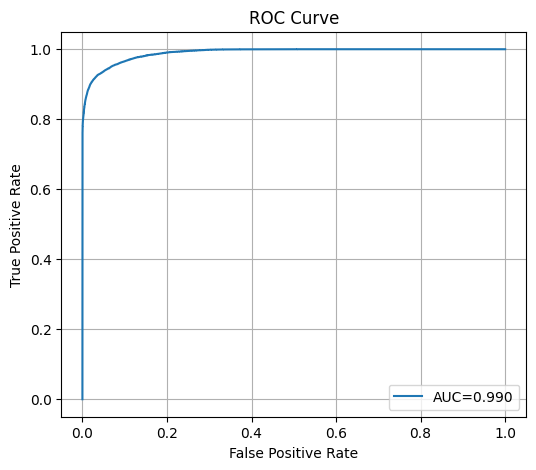

In [23]:
model.eval()
probs, labels = [], []
with torch.no_grad():
    for xb, yb, _ in test_loader:
        xb = xb.to(DEVICE)
        leak, _, _ = model(xb)
        probs.extend(leak.cpu().numpy())
        labels.extend(yb.numpy())

probs = np.array(probs)
labels = np.array(labels)
auc = roc_auc_score(labels, probs)
fpr, tpr, th = roc_curve(labels, probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
threshold = th[best_idx]

preds = (probs >= threshold).astype(int)
precision = precision_score(labels, preds)
recall = recall_score(labels, preds)
f1 = f1_score(labels, preds)

print(f"AUC={auc:.3f}, Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}, Threshold={threshold:.3f}")

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve')
plt.legend(); plt.grid(True); plt.show()


In [24]:
checkpoint = {
    'epoch': epoch,
    'model_state': model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'train_loss': avg_loss,
    'val_loss': val_loss,
}

torch.save(checkpoint, "leak_ann_physics_full_multi_head.pt")
print("Full training checkpoint saved to leak_ann_physics_full.pt")


Full training checkpoint saved to leak_ann_physics_full.pt


In [22]:
INPUT_DIM = (5 * 98)
model = LeakANN(INPUT_DIM)

checkpoint = torch.load("leak_ann_physics_full_multi_head.pt", map_location="cpu")

model.load_state_dict(checkpoint["model_state"])

model.to(DEVICE)
model.eval()


LeakANN(
  (fc1): Linear(in_features=490, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
  (pressure_head): Linear(in_features=128, out_features=32, bias=True)
  (flow_head): Linear(in_features=128, out_features=34, bias=True)
)

In [13]:
import numpy as np
import pandas as pd
import random
from tqdm import tqdm

def compute_mean_std_from_sample(
    all_scenarios, 
    N_SCENARIOS=51, 
    base_path=r"D:\LeakDB_full_data\Hanoi",
    seed=42
):
    random.seed(seed)

    sampled = random.sample(all_scenarios, N_SCENARIOS)
    print(f"Using {len(sampled)} scenarios:", sampled[:10], "...")

    all_values = []  

    for sid in tqdm(sampled, desc="Loading sampled scenarios"):
        df = load_scenario_data(sid, base_path)
        if df is None:
            continue
        X = df.drop(columns=["Leaks", "Timestamps"])
        all_values.append(X) 

    full_df = pd.concat(all_values, ignore_index=True)
    mean = full_df.mean()
    std = full_df.std()

    print("Saved: normalizer_mean.pkl, normalizer_std.pkl")
    return mean, std


In [14]:
all_scenarios = list(range(1, 1000))
mean, std = compute_mean_std_from_sample(
    all_scenarios,
    N_SCENARIOS=51,
    base_path=r"D:\LeakDB_full_data\Hanoi"
)

Using 51 scenarios: [655, 115, 26, 760, 282, 251, 229, 143, 755, 105] ...


Loading sampled scenarios: 100%|██████████| 51/51 [00:22<00:00,  2.25it/s]


Saved: normalizer_mean.pkl, normalizer_std.pkl


In [16]:
(mean, std)

(demand_node_1   -5639.972707
 demand_node_2     145.333445
 demand_node_3     137.162760
 demand_node_4     151.796958
 demand_node_5     259.769230
                     ...     
 flow_link_30     1942.521096
 flow_link_31     1672.346426
 flow_link_32     1290.940504
 flow_link_33     1117.073409
 flow_link_34      968.166116
 Length: 98, dtype: float64,
 demand_node_1    1721.439407
 demand_node_2      46.199733
 demand_node_3      43.180737
 demand_node_4      48.865814
 demand_node_5      82.939076
                     ...     
 flow_link_30      615.194825
 flow_link_31      541.530122
 flow_link_32      430.066917
 flow_link_33      370.354426
 flow_link_34      327.416041
 Length: 98, dtype: float64)

In [30]:
def test_single_scenario(model, scenario_id, threshold, mean, std, base_path=BASE_PATH):

    import seaborn as sns
    from sklearn.metrics import confusion_matrix

    df = load_scenario_data(scenario_id, base_path)
    if df is None:
        print(f"Scenario {scenario_id} not found or incomplete.")
        return

    df_features = df.drop(columns=["Leaks", "Timestamps"])
    df_features_norm = (df_features - mean) / std

    df_norm = df_features_norm.copy()
    df_norm["Leaks"] = df["Leaks"] 
    df_norm["Timestamps"] = df["Timestamps"]

    X, y, last = build_windows_from_df(df_norm)

    model.eval()
    probs = []

    with torch.no_grad():
        xb = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        leak, _, _ = model(xb)
        probs = leak.cpu().numpy()

    threshold = np.percentile(probs, 92) 

    preds = (probs >= threshold).astype(int)
    
    cm = confusion_matrix(y, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix — Scenario {scenario_id}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    tp, fn = cm[1,1], cm[1,0]
    fp, tn = cm[0,1], cm[0,0]

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = (2 * precision * recall) / (precision + recall + 1e-9)
    print(f"Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

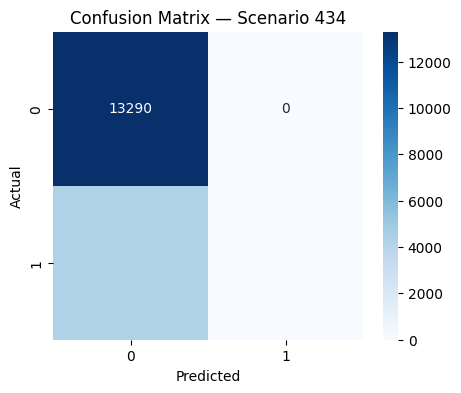

Precision=0.000, Recall=0.000, F1=0.000


In [31]:
test_single_scenario(model, scenario_id=434, threshold=0.05, mean=mean, std=std)